<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-12/TarefaMultiNeuralCensus0519.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pipeline Árvore de Decisão | Treemap Base [Fase 1 - census_data]

## Importar dados do Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/Eu/FATEC/CICLO-V/ML/P1/census.pkl', mode = 'rb') as f:
   X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [6]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

## Treinamento da Árvore de Decisão

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
# cria o modelo de árvore de decisão
arvore_census_data = DecisionTreeClassifier(

    # define o critério de divisão dos nós da árvore 'entropy' utiliza o cálculo de entropia para medir a impureza dos dados
    criterion='entropy',

    # limita a profundidade da árvore para evitar overfitting na base census (alta dimensionalidade após one-hot encoding)
    max_depth=10,

    # exige no mínimo 5 amostras em cada folha, reduzindo ruído em divisões muito específicas
    min_samples_leaf=5,

    # define uma semente fixa para gerar sempre os mesmos resultados aleatórios
    random_state=0
)

# treina a árvore de decisão utilizando:
# X_census_treinamento -> atributos de entrada
# Y_census_treinamento -> classes/respostas corretas
arvore_census_data.fit(
    X_census_treinamento,
    Y_census_treinamento
)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5,
                       random_state=0)

In [10]:
# referência completa dos hiperparâmetros do DecisionTreeClassifier
modelo = DecisionTreeClassifier(

    # controle de poda da árvore (Cost Complexity Pruning) quanto maior o valor, mais simples será a árvore
    ccp_alpha=0.0,

    # define pesos para as classes none = todas as classes possuem o mesmo peso
    class_weight=None,

    # critério usado para medir a qualidade das divisões "entropy" utiliza ganho de informação baseado em entropia
    criterion="entropy",

    # profundidade máxima da árvore None = cresce até o limite dos dados
    max_depth=None,

    # número máximo de atributos analisados em cada divisão None = utiliza todos os atributos disponíveis
    max_features=None,

    # número máximo de nós folha None = sem limite de folhas
    max_leaf_nodes=None,

    # quantidade mínima de amostras em cada folha final
    min_samples_leaf=1,

    # quantidade mínima de amostras para dividir um nó
    min_samples_split=2,

    # fração mínima ponderada necessária em uma folha
    min_weight_fraction_leaf=0.0,

    # define uma semente fixa para reproduzir os mesmos resultados
    random_state=0,

    # estratégia utilizada para escolher a melhor divisão "best" = escolhe a melhor divisão possível
    splitter='best'
)

## Avaliação da Árvore de Decisão

In [11]:
previsoes_arvore = arvore_census_data.predict(X_census_teste)

In [12]:
previsoes_arvore

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [13]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
accuracy_score(Y_census_teste, previsoes_arvore)

0.8544524053224155

In [16]:
from yellowbrick.classifier import ConfusionMatrix

In [17]:
print(classification_report(Y_census_teste, previsoes_arvore))

              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      3693
        >50K       0.78      0.56      0.65      1192

    accuracy                           0.85      4885
   macro avg       0.83      0.75      0.78      4885
weighted avg       0.85      0.85      0.85      4885



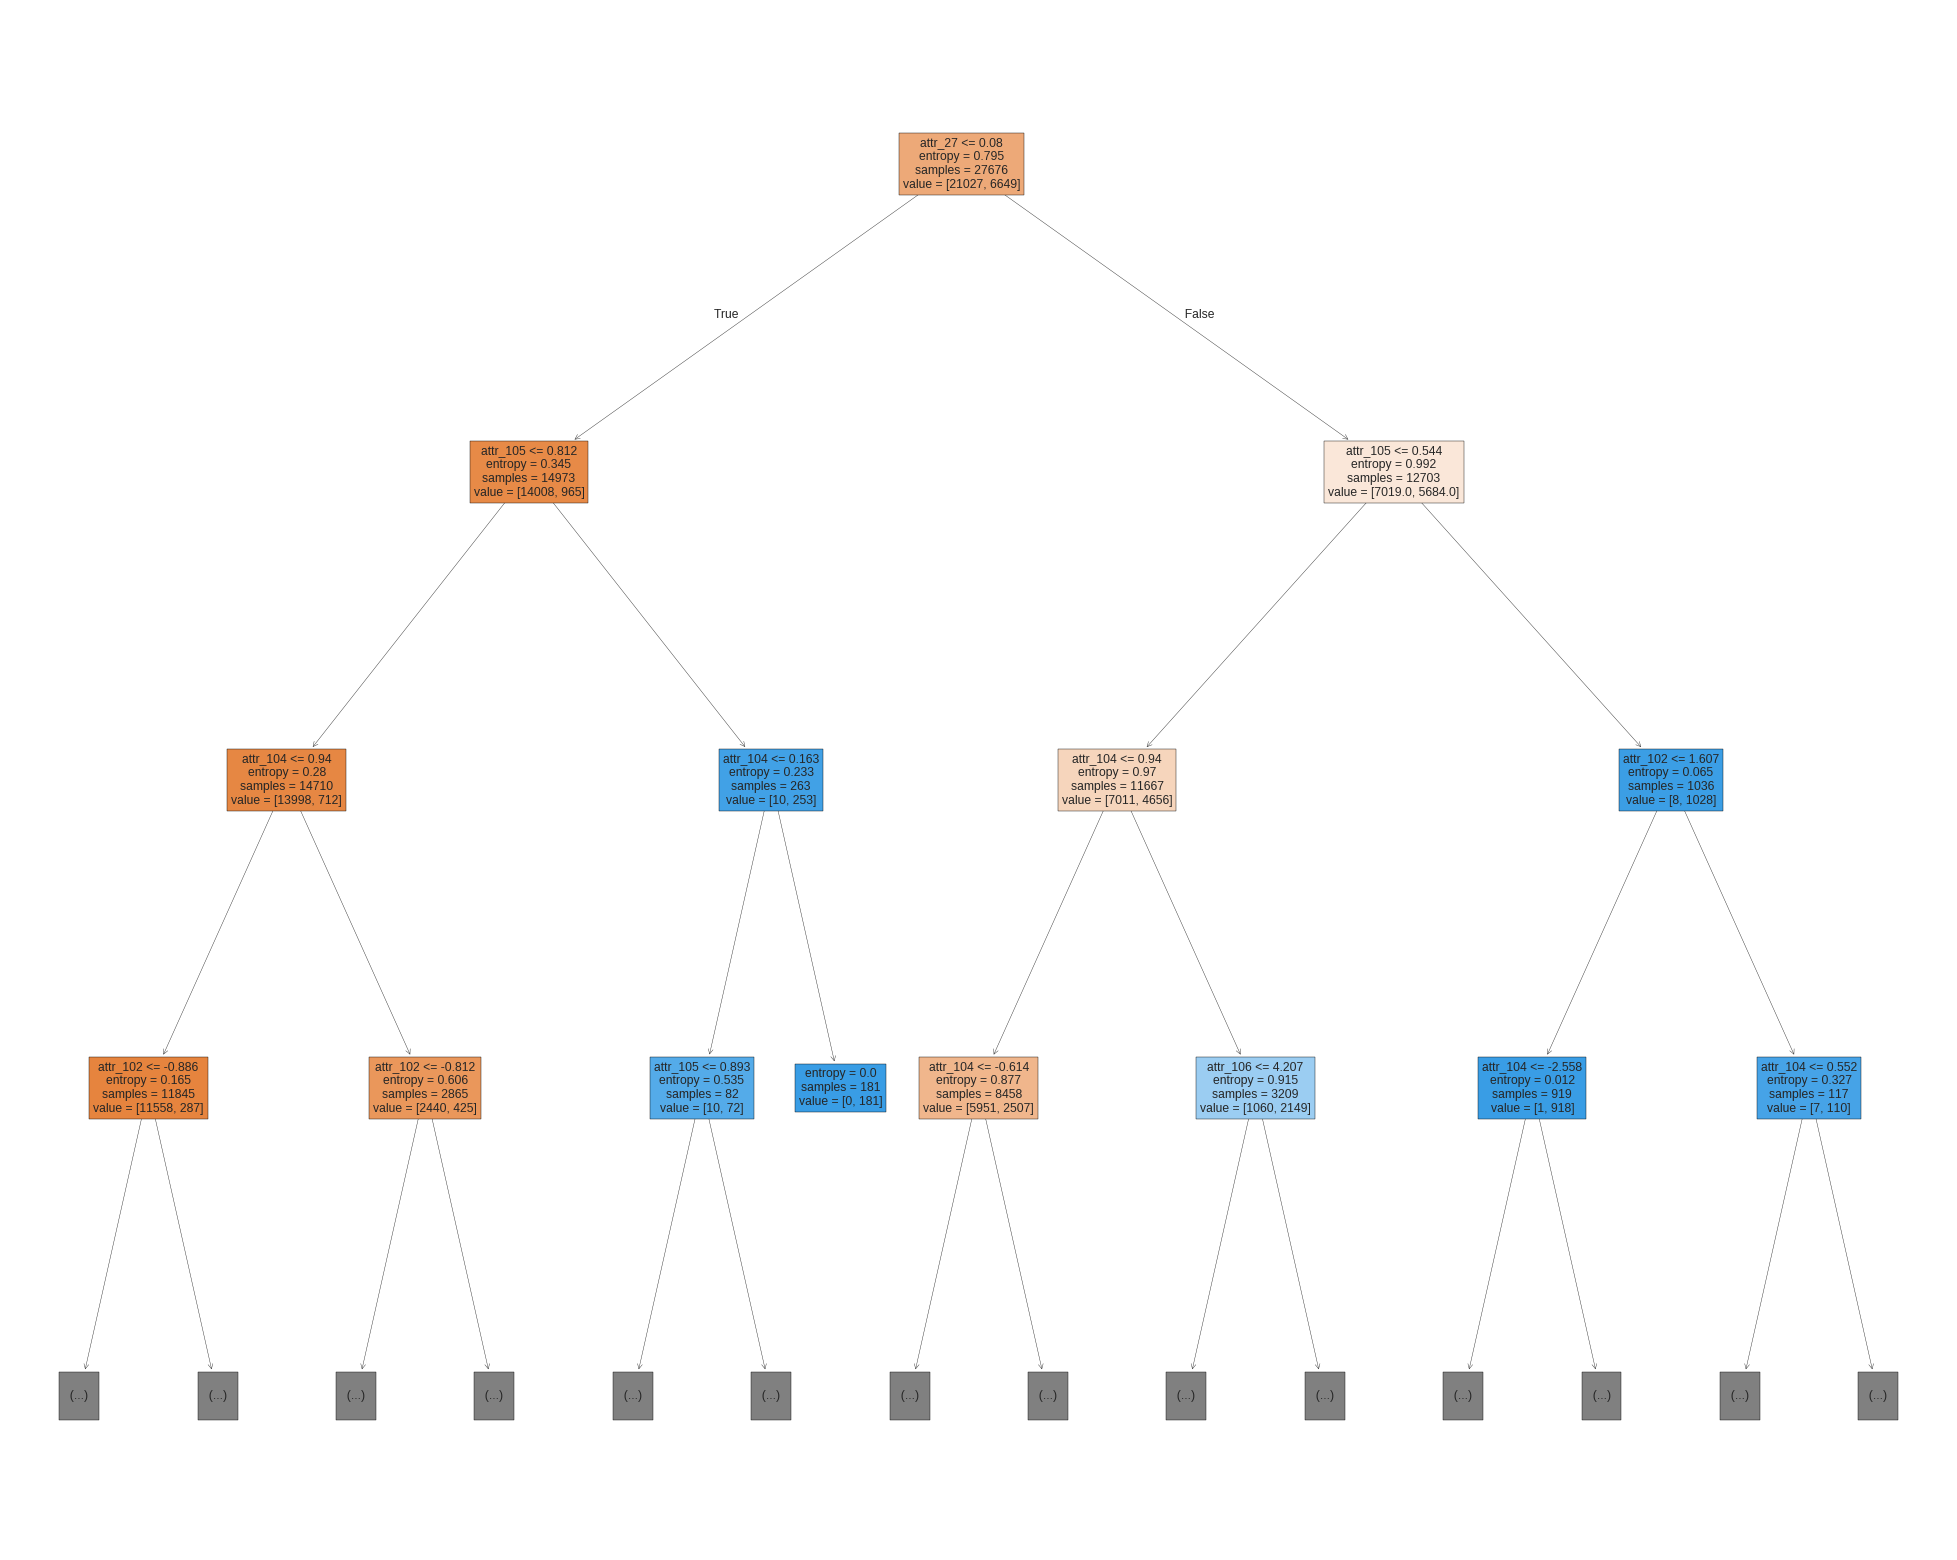

In [18]:
from sklearn import tree

feature_names_census = [f'attr_{i}' for i in range(X_census_treinamento.shape[1])]

fig = plt.figure(figsize=(25,20))

# limita a visualização aos 3 primeiros níveis para a árvore ficar legível na base census
tree.plot_tree(arvore_census_data, feature_names=feature_names_census, max_depth=3, filled=True)
plt.show()